In [ ]:
import pandas as pd

df = pd.read_csv('credit_risk_dataset.csv')

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
df.info()

print("\nFirst 5 Rows:")
display(df.head())

print("\nSummary Statistics:")
display(df.describe())

print("\nMissing Values:")
display(df.isnull().sum())

Shape: (32581, 12)

Columns:
Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  f

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4



Summary Statistics:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000



Missing Values:


,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [ ]:
df['person_emp_length'].fillna(
    df['person_emp_length'].median(),
    inplace=True
)

df['loan_int_rate'].fillna(
    df['loan_int_rate'].median(),
    inplace=True
)

print(df.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


/tmp/ipykernel_1918/2236087201.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(
/tmp/ipykernel_1918/2236087201.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method(

loan_status
0    25473
1     7108
Name: count, dtype: int64


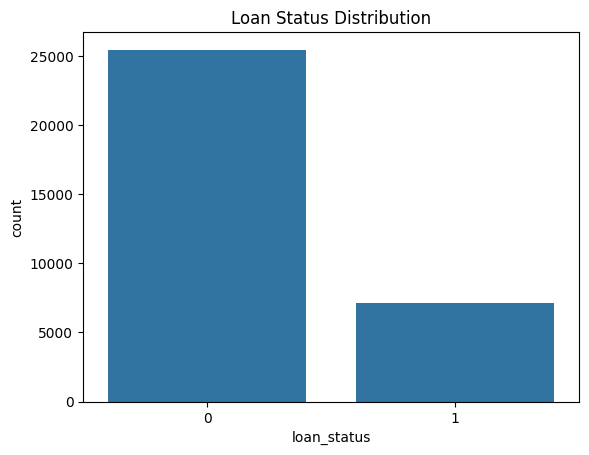

In [ ]:
print(df['loan_status'].value_counts())

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.show()

In [ ]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

print(df_encoded.shape)

df_encoded.head()

(32581, 23)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True


In [ ]:
X = df_encoded.drop(
    'loan_status',
    axis=1
)

y = df_encoded['loan_status']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32581, 22)
y shape: (32581,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(26064, 22)
(6517, 22)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(

    max_iter=5000,

    class_weight='balanced'
)

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr_model.predict(
    X_test_scaled
)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print(
    "Logistic Regression Accuracy:",
    accuracy_score(
        y_test,
        lr_pred
    )
)

print(
    classification_report(
        y_test,
        lr_pred
    )
)

Logistic Regression Accuracy: 0.8138714132269449
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      5095
           1       0.55      0.78      0.65      1422

    accuracy                           0.81      6517
   macro avg       0.74      0.80      0.76      6517
weighted avg       0.85      0.81      0.82      6517



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(

    n_estimators=500,

    max_depth=20,

    class_weight='balanced',

    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

In [ ]:
print(
    "Random Forest Accuracy:",
    accuracy_score(
        y_test,
        rf_pred
    )
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Random Forest Accuracy: 0.9317170477213442
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.97      0.71      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.85      0.89      6517
weighted avg       0.93      0.93      0.93      6517



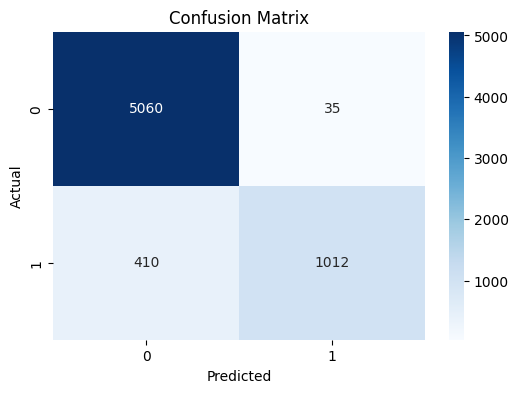

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

loan_percent_income           0.206607
person_income                 0.164950
loan_int_rate                 0.141610
loan_amnt                     0.079546
loan_grade_D                  0.066044
person_home_ownership_RENT    0.058951
person_emp_length             0.049463
person_age                    0.045615
cb_person_cred_hist_length    0.036148
person_home_ownership_OWN     0.019068
dtype: float64


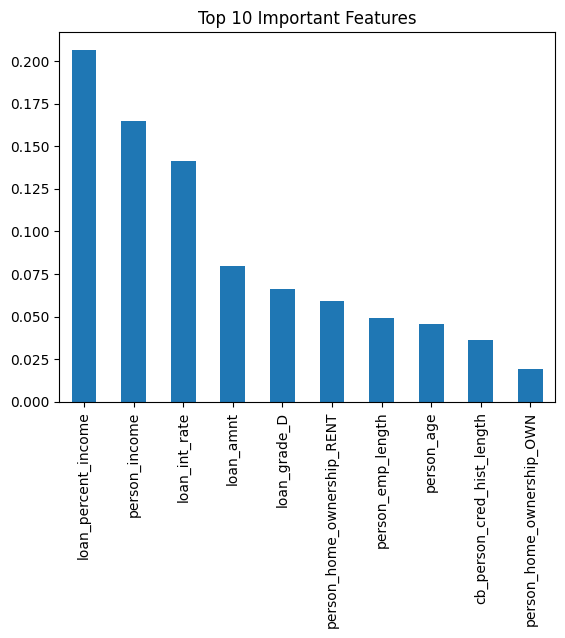

In [ ]:
importance = pd.Series(

    rf_model.feature_importances_,

    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

print(
    importance.head(10)
)

importance.head(10).plot(
    kind='bar'
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [ ]:
print(
    "Logistic Accuracy:",
    accuracy_score(
        y_test,
        lr_pred
    )
)

print(
    "Random Forest Accuracy:",
    accuracy_score(
        y_test,
        rf_pred
    )
)

Logistic Accuracy: 0.8138714132269449
Random Forest Accuracy: 0.9317170477213442
